# Executive Summary

The Pakistan microphone market is categorised into large e-commerce platforms for consumer-grade gear and specialised retailers for content creation equipment and professional studio. This project dives into the Pakistan e-commerce microphone marketplace using advanced engineering and machine learning to answer: 1. How price-sensitive is demand? 2. What drives product sales? 3. Are discounts truly effective? 4. Which sellers dominate the market? 5. What is the optimal revenue-maximizing prices? 6. Can we accurately forecast demand? In this case, we combine econometrics (elasticity modelling), machine learning (XGBoost + GridSearch), and time-series forecasting (Prophet) to build a full pricing intelligence framework.

In [1]:
%pip install xgboost
%pip install prophet
%pip install shap

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


# Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score

from xgboost import XGBRegressor
import shap
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from prophet import Prophet

import warnings

warnings.filterwarnings('ignore')

# Load

In [3]:
df= pd.read_csv("/kaggle/input/datasets/asadullahcreative/e-commerce-microphone-marketplace-dataset/microphone_data.csv")
print (df.head())

                                               title  price  sold_count  \
0  WIRELESS MIC K9 Dual Microphone Mic Plug & Pla...  699.0      1600.0   
1  FunBug K8, K9, K35 Wireless Microphone Collar ...  997.0      1600.0   
2  3.5mm Clip Microphone | Professional Collar Mi...  185.0       723.0   
3  Microphone Collar Mic for Voice Recording Mic ...  199.0       435.0   
4  WIRELESS MIC K9 Dual Microphone Mic Plug & Pla...  649.0       623.0   

   rating  review_count location      seller_name        category  \
0     4.0         694.0   Punjab    MT TRADE ZONE  WIRELESS MIC K   
1     4.0         569.0   Punjab           FUNBUG               F   
2     4.0         118.0   Punjab    MIZUNO SPORTS             NaN   
3     4.0          75.0   Punjab    GADGET HUNTER               M   
4     4.0         141.0   Punjab  MUNEEBTRADERS14  WIRELESS MIC K   

   original_price  discount_percent  ...  seller_tier seller_avg_rating  \
0           699.0              0.00  ...   Top Seller      

In [4]:
df.info()
df.describe()
df.isnull().sum()
df.isna().any()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1360 entries, 0 to 1359
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   title                   1360 non-null   object 
 1   price                   1360 non-null   float64
 2   sold_count              1360 non-null   float64
 3   rating                  1360 non-null   float64
 4   review_count            1360 non-null   float64
 5   location                1360 non-null   object 
 6   seller_name             1360 non-null   object 
 7   category                1210 non-null   object 
 8   original_price          1360 non-null   float64
 9   discount_percent        1360 non-null   float64
 10  is_discounted           1360 non-null   bool   
 11  discount_category       1360 non-null   object 
 12  price_tier              1360 non-null   object 
 13  price_per_rating        1360 non-null   float64
 14  popularity_score        1360 non-null   

title                     False
price                     False
sold_count                False
rating                    False
review_count              False
location                  False
seller_name               False
category                   True
original_price            False
discount_percent          False
is_discounted             False
discount_category         False
price_tier                False
price_per_rating          False
popularity_score          False
review_rate               False
value_score               False
price_vs_category_avg      True
is_top_rated               True
seller_tier                True
seller_avg_rating         False
seller_total_sales        False
discount_effectiveness    False
market_position           False
review_density            False
virality_score            False
price_capped              False
sold_count_capped         False
review_count_capped       False
dtype: bool

# Data Cleaning & Preprocessing

In [5]:
for col in df.columns:
    if df[col].dtype in [np.float64, np.int64]:
        df[col].fillna(df[col].median (), inplace=True)
    else:
        df[col].fillna('unknown', inplace=True)

print (df.isnull().sum())

title                     0
price                     0
sold_count                0
rating                    0
review_count              0
location                  0
seller_name               0
category                  0
original_price            0
discount_percent          0
is_discounted             0
discount_category         0
price_tier                0
price_per_rating          0
popularity_score          0
review_rate               0
value_score               0
price_vs_category_avg     0
is_top_rated              0
seller_tier               0
seller_avg_rating         0
seller_total_sales        0
discount_effectiveness    0
market_position           0
review_density            0
virality_score            0
price_capped              0
sold_count_capped         0
review_count_capped       0
dtype: int64


# Engineered Features

Engineered variables helps strategic analysis beyond raw sales data. They are as shown below

Product-Level
price
rating
review_count
value_score
price_per_rating
price_vs_category_avg
is_top_rated
price_tier

Seller-Level
seller_tier
seller_avg_rating
seller_total_sales

Market/Behavioral
discount_percent
discount_effectiveness
popularity_score
review_rate
review_density
virality_score
market_position

Target Variable: sold_count

# Market Overview

In [6]:
#Main KPIs

Total_Units_Sold= df['sold_count'].sum()
Average_Market_Price = df['price'].mean()
Average_Rating = df['rating'].mean()
Total_Revenue = (df['sold_count'] * df['price']).sum()
Weighted_rating = np.average(
    df['rating'],
    weights=df['review_count']
)

# seller Tier Market Share
Tier_sales = df.groupby('seller_tier')['sold_count'].sum()
Tier_share = (Tier_sales/Total_Units_Sold)*100

print("Microphone Market Overview")
print("="*50)

print(f" Total Units Sold: {Total_Units_Sold:,.0f}")
print(f"Total Revenue: PKR {Total_Revenue:,.0f}")
print(f"Average Price: PKR {Average_Market_Price:,.2f}")
print(f"Average Rating (Unweighted): {Average_Rating :.2f}")
print(f"Average Rating (Weighted by Reviews): {Weighted_rating:.2f}")

print("\n Seller Tier Market Share (by Units Sold)")
print("-"*50)

for Tier, share in Tier_share.sort_values(ascending=False).items():
    print(f"{Tier}: {share:.2f}%")

Microphone Market Overview
 Total Units Sold: 83,832
Total Revenue: PKR 162,041,568
Average Price: PKR 3,680.70
Average Rating (Unweighted): 4.06
Average Rating (Weighted by Reviews): 3.98

 Seller Tier Market Share (by Units Sold)
--------------------------------------------------
Top Seller: 37.65%
Established: 30.66%
unknown: 15.55%
Growing: 11.22%
Starter: 4.92%


# Log-Log Price Elasticity

In [7]:
df["log_price"] = np.log(df['price'])
df['log_sales'] = np.log(df['sold_count']+1)

X=sm.add_constant(df['log_price'])
elastic_model = sm.OLS(df['log_sales'], X).fit()
print(elastic_model.summary())
elasticity = elastic_model.params['log_price']
print('Price Elasticity:', round(elasticity,2))

                            OLS Regression Results                            
Dep. Variable:              log_sales   R-squared:                       0.044
Model:                            OLS   Adj. R-squared:                  0.043
Method:                 Least Squares   F-statistic:                     62.77
Date:                Sun, 22 Feb 2026   Prob (F-statistic):           4.81e-15
Time:                        07:05:55   Log-Likelihood:                -2882.8
No. Observations:                1360   AIC:                             5770.
Df Residuals:                    1358   BIC:                             5780.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.0841      0.327     12.502      0.0

# Non Linear Demand Curve

                            OLS Regression Results                            
Dep. Variable:             sold_count   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     5.351
Date:                Sun, 22 Feb 2026   Prob (F-statistic):            0.00484
Time:                        07:05:55   Log-Likelihood:                -9232.5
No. Observations:                1360   AIC:                         1.847e+04
Df Residuals:                    1357   BIC:                         1.849e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            76.1272      7.394     10.296

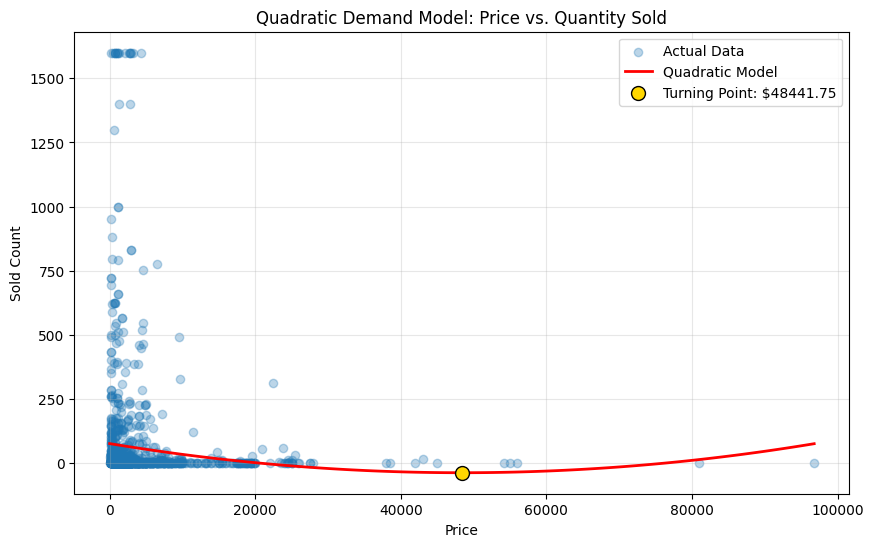

Demand Turning Point: 48441.75


In [8]:
df['price_squared'] = df['price']**2
X_quad = sm.add_constant(df[['price', 'price_squared']])
y = df['sold_count']

# 2. Fit the Quadratic OLS Model
quad_model = sm.OLS(y, X_quad).fit()
print(quad_model.summary())

# 3. Calculate the Turning Point (Vertex: -b1 / 2*b2)
b1 = quad_model.params['price']
b2 = quad_model.params['price_squared']
turning_price = -b1 / (2 * b2)

# 4. Visualization
p_range = np.linspace(df['price'].min(), df['price'].max(), 100)
# Predicted values for the curve
q_pred = quad_model.params['const'] + b1*p_range + b2*(p_range**2)
turning_q = quad_model.params['const'] + b1*turning_price + b2*(turning_price**2)

plt.figure(figsize=(10, 6))
plt.scatter(df['price'], df['sold_count'], alpha=0.3, label='Actual Data')
plt.plot(p_range, q_pred, color='red', lw=2, label='Quadratic Model')
plt.scatter(turning_price, turning_q, color='gold', edgecolor='black', s=100, 
            label=f'Turning Point: ${turning_price:.2f}', zorder=5)

plt.title('Quadratic Demand Model: Price vs. Quantity Sold')
plt.xlabel('Price')
plt.ylabel('Sold Count')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Demand Turning Point: {round(turning_price, 2)}")


# Seller Fixed Effects Model

In [9]:
seller_dummies =pd.get_dummies(df['seller_tier'], drop_first=True).astype(int)
X_fe=pd.concat([
    df[['price','rating','value_score','discount_percent']],
    seller_dummies
],axis=1)
X_fe=sm.add_constant(X_fe)
seller_fe_model = sm.OLS(df['sold_count'],X_fe).fit()
print(seller_fe_model.summary())

                            OLS Regression Results                            
Dep. Variable:             sold_count   R-squared:                       0.689
Model:                            OLS   Adj. R-squared:                  0.687
Method:                 Least Squares   F-statistic:                     374.4
Date:                Sun, 22 Feb 2026   Prob (F-statistic):               0.00
Time:                        07:05:55   Log-Likelihood:                -8443.3
No. Observations:                1360   AIC:                         1.690e+04
Df Residuals:                    1351   BIC:                         1.695e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -3149.5476     79.774  

# Interactions Effects

In [10]:
# Does discount compensate for weak ratings?
df['discount_rating_interaction']=df['discount_percent']*df['rating']
X_int=sm.add_constant(df[['price','rating','discount_percent','discount_rating_interaction']])
interaction_model=sm.OLS(df['sold_count'],X_int).fit()
print(interaction_model.summary())

                            OLS Regression Results                            
Dep. Variable:             sold_count   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                  0.020
Method:                 Least Squares   F-statistic:                     7.767
Date:                Sun, 22 Feb 2026   Prob (F-statistic):           3.46e-06
Time:                        07:05:55   Log-Likelihood:                -9222.5
No. Observations:                1360   AIC:                         1.845e+04
Df Residuals:                    1355   BIC:                         1.848e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const             

# Machine Learning Model (Pipeline + GrideSearch)

In [11]:
numerical_features=[
     "price",
    "rating",
    "review_count",
    "value_score",
    "price_vs_category_avg",
    "popularity_score",
    "review_density",
    "virality_score",
    "seller_avg_rating",
    "seller_total_sales",
    "discount_percent"
]
categorical_features=[
    "price_tier",
    "seller_tier",
    "market_position",
    "discount_category"
]

X=df[numerical_features + categorical_features]
y= df['sold_count']
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

#split data in train and test sets
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

#create XGBoostClassifier model
XGB=XGBRegressor(Objective='reg:squarederror', random_state=42)
pipeline=Pipeline([
    ('preprocessor', preprocessor),
    ('XGB', XGB)
])
#Define the parameter grid 
param_grid={
    'XGB__n_estimators':[300,500],
    'XGB__max_depth':[4,6,8],
    'XGB__learning_rate':[0.03,0.05],
    'XGB__subsample':[0.8,1]
}



#perform a grid search
grid = GridSearchCV(pipeline, param_grid, cv=3, scoring='r2', n_jobs=-1)
grid.fit(X_train, y_train)

preds = grid.predict(X_test)

print('R2:', round(r2_score(y_test, preds),3))
print('MAE:', round(mean_absolute_error(y_test, preds), 2))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [07:05:58] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "Objective" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [07:05:58] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "Objective" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [07:05:58] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "Objective" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [07:05:58] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "Objective" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [07:05:58] WARNING: /workspace/src/learner.cc:790: 
Pa

R2: 0.996
MAE: 2.24


# SHAP Model

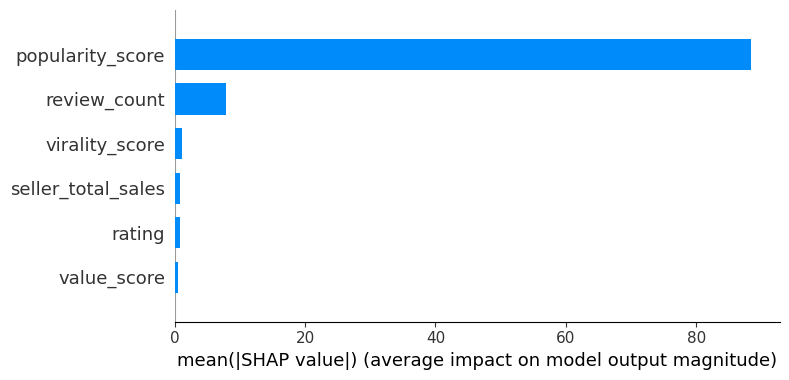

In [12]:
# Get best model
best_model = grid.best_estimator_

# Transform test data
preprocessor = best_model.named_steps['preprocessor']
X_transformed = preprocessor.transform(X_test)

# Get feature names from preprocessor
feature_names = preprocessor.get_feature_names_out()

# Convert to DataFrame (IMPORTANT FIX)
X_transformed_df = pd.DataFrame(
    X_transformed,
    columns=feature_names,
    index=X_test.index
)

# Optional: clean feature names
X_transformed_df.columns = [
    name.split("__")[-1] for name in X_transformed_df.columns
]

# Use TreeExplainer for XGBoost (more stable)
explainer = shap.TreeExplainer(best_model.named_steps['XGB'])
shap_values = explainer.shap_values(X_transformed_df)

plt.figure()
shap.summary_plot(
    shap_values,
    X_transformed_df,
    plot_type="bar",
    show=False,
    max_display=6
)
plt.tight_layout()
plt.show()

# Competitive Position Clustering

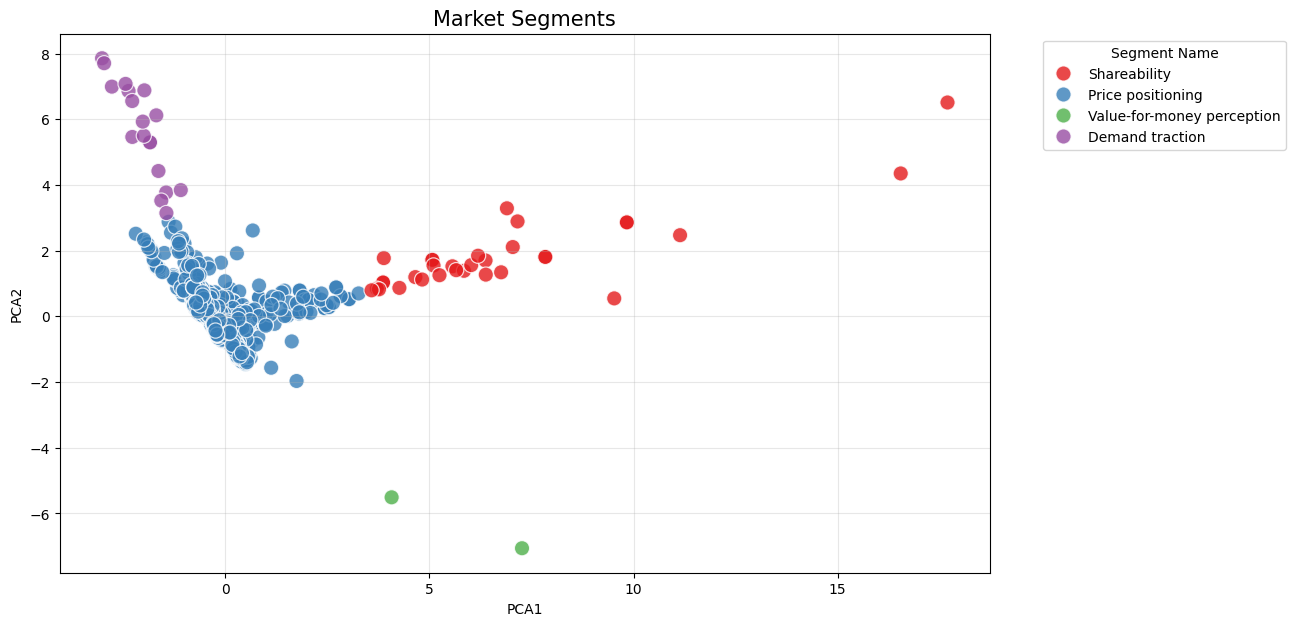

--- Cluster Profiles (Mean Values) ---


,price_vs_category_avg,value_score,virality_score,popularity_score,review_density,sold_count
market_cluster,,,,,,
Demand traction,909.155575,55.066188,0.296296,5.277778,0.024846,1.055556
Price positioning,-14.570152,61.575649,1.835821,133.853976,10.159167,33.706422
Shareability,-49.042657,67.796733,3.564110,4786.375000,641.361053,1214.531250
Value-for-money perception,-41.691399,65.851085,274.750000,2030.500000,1.408451,430.000000


In [13]:


features_list = ['price_vs_category_avg', 'value_score', 'virality_score', 'popularity_score', 'review_density']
X = df[features_list]
scaled = StandardScaler().fit_transform(X)

# 2. Clustering
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster_id'] = kmeans.fit_predict(scaled)

# 3. Naming the Clusters (Based on feature averages)
cluster_map = {
    0: "Price positioning",
    1: "Value-for-money perception",
    2: "Shareability",
    3: "Demand traction",
    4: "Engagement intensity"
}
df['market_cluster'] = df['cluster_id'].map(cluster_map)

# 4. PCA for Visualization
pca = PCA(n_components=2)
pca_results = pca.fit_transform(scaled)
pca_df = pd.DataFrame(pca_results, columns=['PCA1', 'PCA2'])
pca_df['market_cluster'] = df['market_cluster'].values

# 5. Plotting
plt.figure(figsize=(12, 7))
sns.scatterplot(
    x='PCA1', y='PCA2', 
    hue='market_cluster', 
    data=pca_df, 
    palette='Set1', 
    s=120, 
    alpha=0.8
)
plt.title('Market Segments', fontsize=15)
plt.legend(title='Segment Name', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

# 6. Show Cluster Values (Profiles)
print("--- Cluster Profiles (Mean Values) ---")
profiles = df.groupby('market_cluster')[features_list + ['sold_count']].mean()
display(profiles) 

# Revenue Optimization

In [14]:
base_price=df['price'].mean()
base_sales=df['sold_count'].mean()

def revenue(price):
    predicted=base_sales*(price/base_price)**elasticity
    return price*predicted

price_range=np.linspace(base_price*0.7,base_price*1.3,100)
revenues=[revenue(p) for p in price_range]
optimal_price = price_range[np.argmax(revenues)]
print("Elasticity Optimal Price: PKR", round(optimal_price,2))

Elasticity Optimal Price: PKR 4784.91
